# Convolutional Neural Network

In [1]:
# Libraries
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.models import Sequential
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [7]:
y_train[0]

array([6], dtype=uint8)

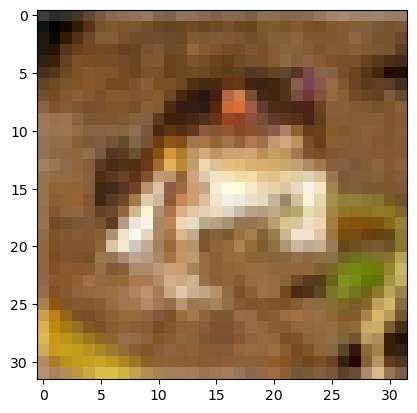

In [8]:
plt.imshow(x_train[0])

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

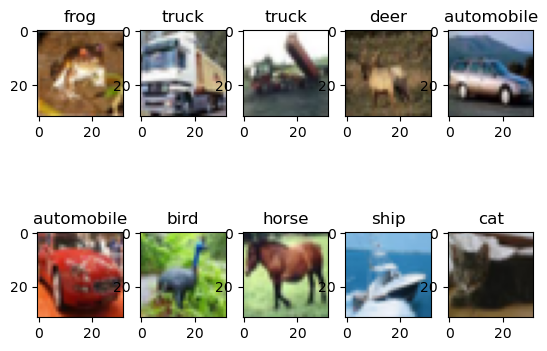

In [10]:
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])

In [11]:
y_train[0]

array([6], dtype=uint8)

In [12]:
# scaling of data
x_train = x_train/255.0
x_test = x_test / 255.0

In [35]:
# Build CNN model
model = Sequential([
                        Input(shape = (32,32,3)),
                        Conv2D(32, (3,3), activation = 'relu'),
                        Conv2D(16, (3,3), activation = 'relu'),
                        Conv2D(8, (3,3), activation = 'relu'),
                        MaxPooling2D(2,2),
                        Flatten(),
                        Dense(128, activation = 'relu'),
                        Dropout(0.2),
                        Dense(64, activation = 'relu'),
                        Dropout(0.1),
                        Dense(32, activation = 'relu'),
                        Dense(10, activation = 'softmax')
])

In [36]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ["accuracy"])

In [37]:
history = model.fit(x_train, y_train, epochs = 1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.4106 - loss: 1.6034


In [38]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5170 - loss: 1.3108


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


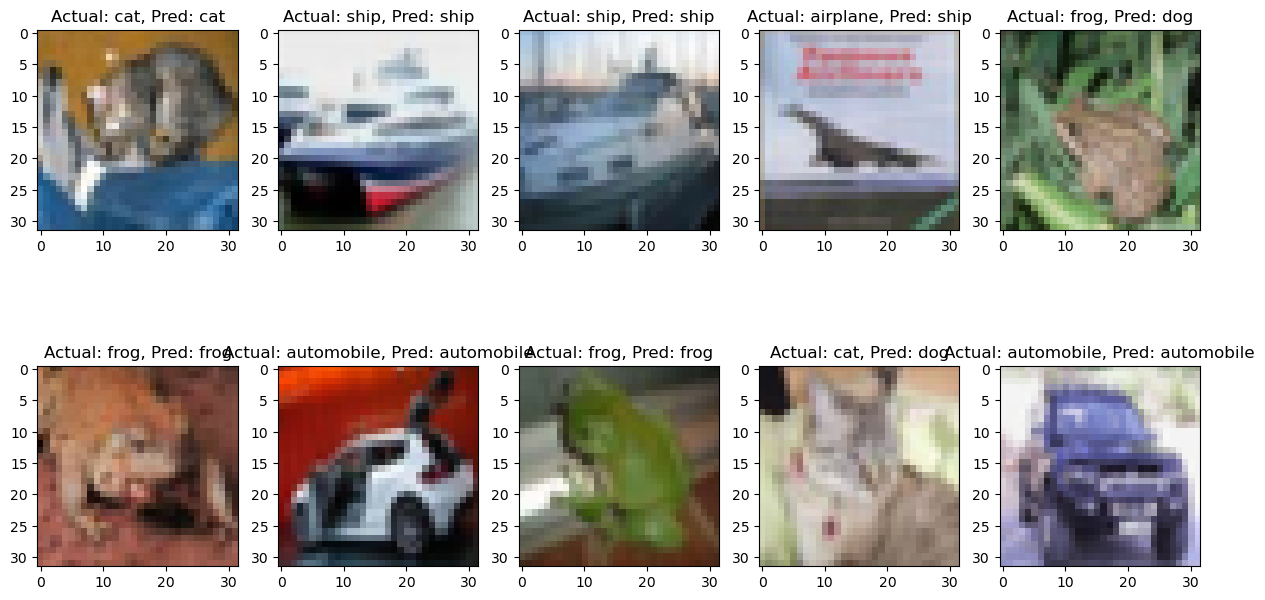

In [50]:
import numpy as np
plt.figure(figsize = (15, 8))
for i in range(10):
    img = x_test[i]
    img_expended = np.expand_dims(img, axis = 0)
    prediction = model.predict(img_expended)
    
    predicted_label = np.argmax(prediction)

    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    plt.title(f"Actual: {class_names[y_test[i][0]]}, Pred: {class_names[predicted_label]}")